<a href="https://colab.research.google.com/github/shafiq73/2024/blob/main/house_prices_advanced_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1 = pd.read_csv('/content/house-price-test.csv')
df2 = pd.read_csv('/content/house-price-train.csv')

# If SalePrice is not in test file, add it with default value 0
if "SalePrice" not in df2.columns:
    df2["SalePrice"] = 0

# Combine both files
df = pd.concat([df1, df2], axis=0)

# Set Id as index
df = df.set_index('Id')

# Show first rows
df.head()

In [ ]:
# Show first rows
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,NaN
1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,NaN
1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,NaN
1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,NaN
1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,NaN


In [ ]:
df_null = df[df.isnull().sum()[df.isnull().sum() > 0].index]

In [ ]:
df_null.head()

,MSZoning,LotFrontage,Alley,Utilities,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,BsmtQual,BsmtCond,...,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PoolQC,Fence,MiscFeature,SaleType,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1461,RH,80.0,NaN,AllPub,VinylSd,VinylSd,NaN,0.0,TA,TA,...,Unf,1.0,730.0,TA,TA,NaN,MnPrv,NaN,WD,NaN
1462,RL,81.0,NaN,AllPub,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,...,Unf,1.0,312.0,TA,TA,NaN,NaN,Gar2,WD,NaN
1463,RL,74.0,NaN,AllPub,VinylSd,VinylSd,NaN,0.0,Gd,TA,...,Fin,2.0,482.0,TA,TA,NaN,MnPrv,NaN,WD,NaN
1464,RL,78.0,NaN,AllPub,VinylSd,VinylSd,BrkFace,20.0,TA,TA,...,Fin,2.0,470.0,TA,TA,NaN,NaN,NaN,WD,NaN
1465,RL,43.0,NaN,AllPub,HdBoard,HdBoard,NaN,0.0,Gd,TA,...,RFn,2.0,506.0,TA,TA,NaN,NaN,NaN,WD,NaN


<Axes: ylabel='Id'>

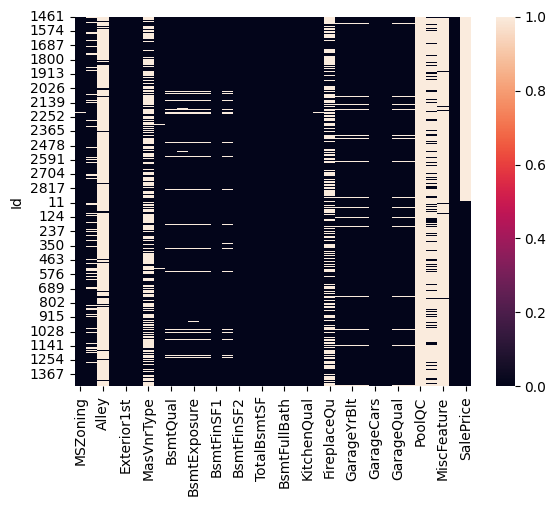

In [ ]:
sns.heatmap(df_null.isnull())

In [ ]:
df_objects = df[df.select_dtypes(include=['object']).columns]
columns_to_drop = df_objects.isna().sum()[df_objects.isna().sum() > 1100].index
df = df.drop(columns=columns_to_drop, axis=1)

In [ ]:
df_objects = df[df.select_dtypes(include=['object']).columns]
df_objects = df_objects.fillna('null')
df_objects_encoded = pd.get_dummies(df_objects)

In [ ]:
df_objects.columns

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [ ]:
df_objects['Utilities'].value_counts()

,count
Utilities,
AllPub,2916
null,2
NoSeWa,1


In [ ]:
df_objects.head()

,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,...,Electrical,KitchenQual,Functional,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
1461,RH,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,...,SBrkr,TA,Typ,Attchd,Unf,TA,TA,Y,WD,Normal
1462,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,...,SBrkr,Gd,Typ,Attchd,Unf,TA,TA,Y,WD,Normal
1463,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,...,SBrkr,TA,Typ,Attchd,Fin,TA,TA,Y,WD,Normal
1464,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,...,SBrkr,Gd,Typ,Attchd,Fin,TA,TA,Y,WD,Normal
1465,RL,Pave,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,...,SBrkr,Gd,Typ,Attchd,RFn,TA,TA,Y,WD,Normal


In [ ]:
df_objects_encoded.head()

,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,MSZoning_null,Street_Grvl,Street_Pave,LotShape_IR1,LotShape_IR2,...,SaleType_New,SaleType_Oth,SaleType_WD,SaleType_null,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,,,,,,,,,,,,,,,,,,,,,
1461,False,False,True,False,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,False
1462,False,False,False,True,False,False,False,True,True,False,...,False,False,True,False,False,False,False,False,True,False
1463,False,False,False,True,False,False,False,True,True,False,...,False,False,True,False,False,False,False,False,True,False
1464,False,False,False,True,False,False,False,True,True,False,...,False,False,True,False,False,False,False,False,True,False
1465,False,False,False,True,False,False,False,True,True,False,...,False,False,True,False,False,False,False,False,True,False


In [ ]:
df_objects['MSZoning'].value_counts()

,count
MSZoning,
RL,2265
RM,460
FV,139
RH,26
C (all),25
null,4


In [ ]:
for i in df_objects_encoded.columns:
    if 'null' in i:
        df_objects_encoded = df_objects_encoded.drop(i, axis=1)
        print(i)

MSZoning_null
Utilities_null
Exterior1st_null
Exterior2nd_null
BsmtQual_null
BsmtCond_null
BsmtExposure_null
BsmtFinType1_null
BsmtFinType2_null
Electrical_null
KitchenQual_null
Functional_null
GarageType_null
GarageFinish_null
GarageQual_null
GarageCond_null
SaleType_null


In [ ]:
df_objects_encoded.head()

,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,LotShape_IR1,LotShape_IR2,LotShape_IR3,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,,,,,,,,,,,,,,,,,,,,,
1461,False,False,True,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,True,False
1462,False,False,False,True,False,False,True,True,False,False,...,False,False,False,True,False,False,False,False,True,False
1463,False,False,False,True,False,False,True,True,False,False,...,False,False,False,True,False,False,False,False,True,False
1464,False,False,False,True,False,False,True,True,False,False,...,False,False,False,True,False,False,False,False,True,False
1465,False,False,False,True,False,False,True,True,False,False,...,False,False,False,True,False,False,False,False,True,False


In [ ]:
new_df = pd.concat([df,df_objects_encoded],axis=1)

In [ ]:
len(new_df.columns)

304

In [ ]:
len(df.columns),len (df_objects_encoded.columns)

(74, 230)

In [ ]:
new_df = new_df.drop(df.select_dtypes(include=['object']).columns, axis=1)

new_df.isna().sum()[new_df.isna().sum() > 0]

,0
LotFrontage,486
MasVnrArea,23
BsmtFinSF1,1
BsmtFinSF2,1
BsmtUnfSF,1
TotalBsmtSF,1
BsmtFullBath,2
BsmtHalfBath,2
GarageYrBlt,159
GarageCars,1


In [ ]:
list(new_df.isna().sum()[new_df.isna().sum() > 0].index)


['LotFrontage',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'BsmtFullBath',
 'BsmtHalfBath',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'SalePrice']

In [ ]:
Mode_columns = ['GarageCars','GarageYrBlt','BsmtFullBath','BsmtHalfBath']
Mean_columns = ['LotFrontage','MasVnrArea','BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'GarageArea']
for i in Mode_columns:
    new_df[i] = new_df[i].fillna(new_df[i].mode()[0])
for i in Mean_columns:
    new_df[i] = new_df[i].fillna(np.round(new_df[i].mean()))

new_df.isna().sum()[new_df.isna().sum() > 0]

,0
SalePrice,1459


In [ ]:
testing_data = new_df[0:len(df1)]
training_data = new_df[len(df1):]
testing_data = testing_data.drop('SalePrice', axis=1)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

In [ ]:
X = training_data.drop(columns='SalePrice')
Y = training_data['SalePrice']
X_train,X_test,Y_train,Y_test = train_test_split(X,Y ,test_size=0.2)#, random_state=42)
print(X_train.shape, Y_train.shape)

(1168, 266) (1168,)


In [ ]:
model_1 = LinearRegression()
model_1.fit(X,Y)
Y_pred = model_1.predict(X_test)
mean_squared_error(Y_test, Y_pred)

471642296.5030648

In [ ]:
model_2 = XGBRegressor(n_estimators=1000, learning_rate=0.1)
model_2.fit(X_train,Y_train)
Y_pred = model_2.predict(X_test)
mean_squared_error(Y_test, Y_pred)


1382971751.951801

In [ ]:
model_3 = RandomForestRegressor(n_estimators=100)
model_3.fit(X_train,Y_train)
Y_pred = model_3.predict(X_test)
mean_squared_error(Y_test, Y_pred)

1171971981.109408

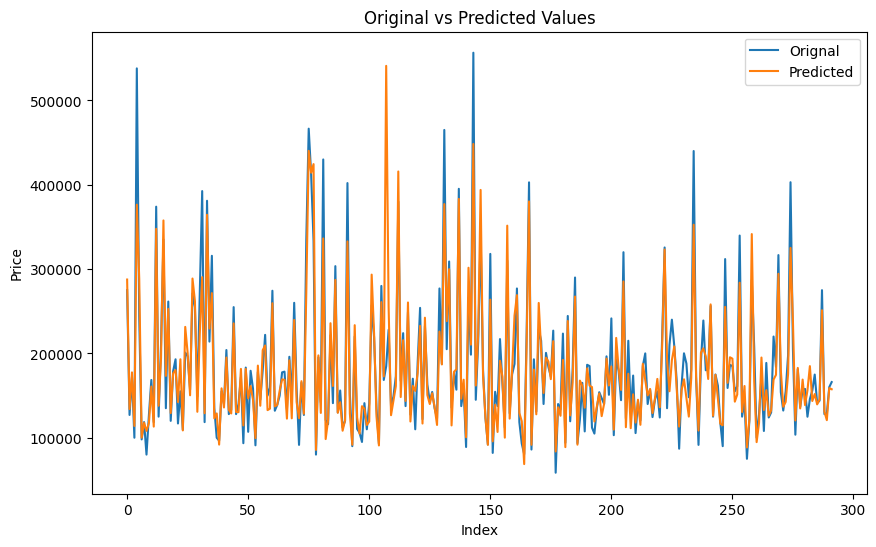

/tmp/ipython-input-1511158873.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


[]

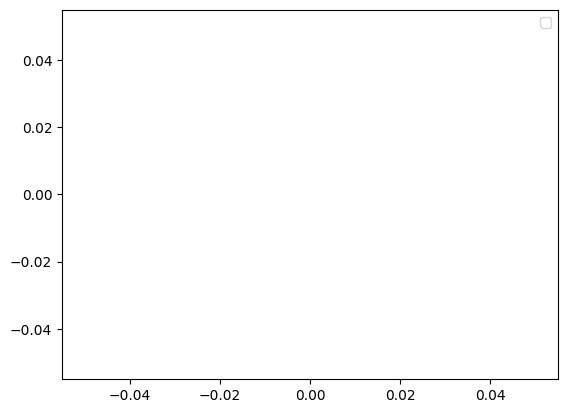

In [ ]:
sort_indices = np.argsort(Y_test)
# plot
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(Y_test)), Y_test, label='Orignal')
plt.plot(np.arange(len(Y_test)), Y_pred, label='Predicted')
plt.xlabel('Index')
plt.ylabel('Price')
plt.title('Original vs Predicted Values')
plt.legend()
plt.show()
plt.legend()
plt.plot()

In [ ]:
pred = model_2.predict(testing_data)
final = pd.DataFrame()
final['Id'] = testing_data.index
final['SalePrice'] = pred
# Write Dataframe to a csv with outindex
final.to_csv('output.csv',index=False)